In [1]:
import sys
from pathlib import Path

# Find the repo root (the directory containing pyproject.toml) so the
# notebook can be run from anywhere.
_p = Path.cwd().resolve()
while _p.parent != _p and not (_p / "pyproject.toml").exists():
    _p = _p.parent
REPO_ROOT = _p
sys.path.insert(0, str(REPO_ROOT))
DATA_DIR = REPO_ROOT / "data"

import pandas as pd
from pathlib import Path
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [2]:
file = DATA_DIR / 'Nat_Gas.csv'
df_gas = pd.read_csv(file)
df_gas['Dates'] = pd.to_datetime(df_gas['Dates'])
df_gas = df_gas.sort_values('Dates')
print(f"Data points: {len(df_gas)}")
print(df_gas.head())

Data points: 48
       Dates  Prices
0 2020-10-31    10.1
1 2020-11-30    10.3
2 2020-12-31    11.0
3 2021-01-31    10.9
4 2021-02-28    10.9


/sessions/friendly-laughing-hypatia/tmp/ipykernel_9/589999823.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_gas['Dates'] = pd.to_datetime(df_gas['Dates'])


In [3]:
df_gas['Dates'] = pd.to_datetime(df_gas['Dates'], format='%Y-%m-%d')

Text(0.5, 0, 'Months since start')

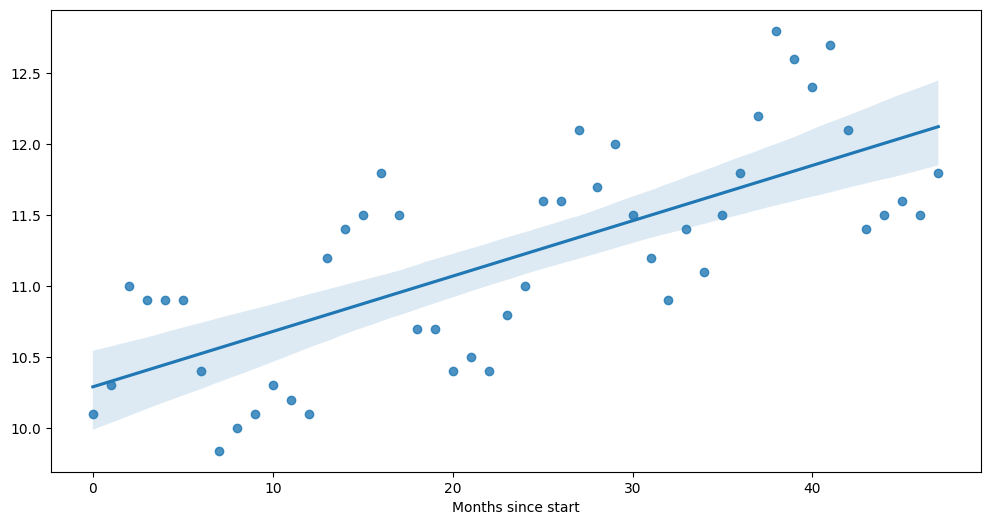

In [4]:
df_gas = df_gas.sort_values('Dates')
m = df_gas['Dates'].dt.year * 12 + df_gas['Dates'].dt.month
t = (m - m.min()).to_numpy().astype(float)  
y = df_gas['Prices'].to_numpy().astype(float)

plt.figure(figsize=(12,6))
sns.regplot(x=t, y=y)
plt.xlabel('Months since start')

In [5]:
#Task 1 - Price Prediction and Fitting
from scipy.optimize import curve_fit

# model: constant + linear + quadratic + yearly sine/cosine
# we can see clear linear fuction a + b*t, however on the edges the CI looks bigger so let's try to see if t^2
#going to be needed. 
# sin & cos give us a smooth seasonal shape with one peak and one trough per year, 
#which is exactly what heating-driven gas demand suggests from the report.
def f(t, a, b, c, d, e):
    P = 12.0
    return a + b*t + e*t*t + c*np.sin(2*np.pi*t/P) + d*np.cos(2*np.pi*t/P)

popt, _ = curve_fit(f, t, y, maxfev=20000)
a, b, c, d, e = popt #finding weights

print(f"f(t) = {a:.4f} + {b:.4f}·t + {e:.10f}·t² + {c:.4f}·sin(2π·t/12) + {d:.4f}·cos(2π·t/12)")
# t = months since the first date

f(t) = 10.1233 + 0.0471·t + -0.0000322653·t² + 0.6900·sin(2π·t/12) + -0.0374·cos(2π·t/12)


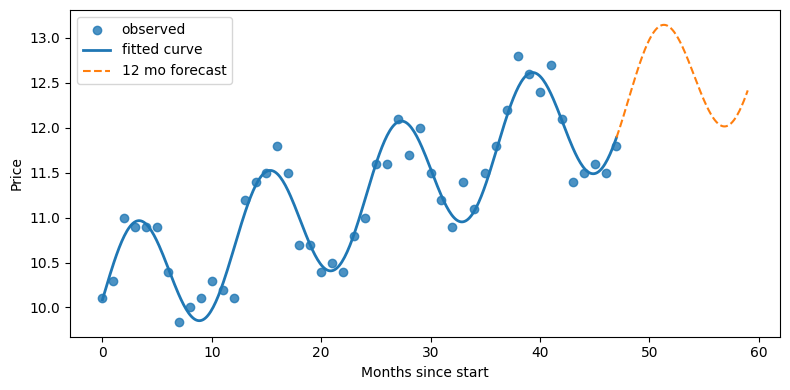

In [6]:
#Scatter plot of the Original Points (t = months since start)
plt.figure(figsize=(8,4))
plt.scatter(t, y, label="observed", alpha=0.8)

#smooth fitted curve over the observed range
t_grid = np.linspace(t.min(), t.max(), 400)
y_grid = f(t_grid, *popt)
plt.plot(t_grid, y_grid, label="fitted curve", linewidth=2)

# extend 12 months into the future
t_future = np.linspace(t.max(), t.max() + 12, 240)
y_future = f(t_future, *popt)
plt.plot(t_future, y_future, linestyle="--", label="12 mo forecast")

plt.xlabel("Months since start")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

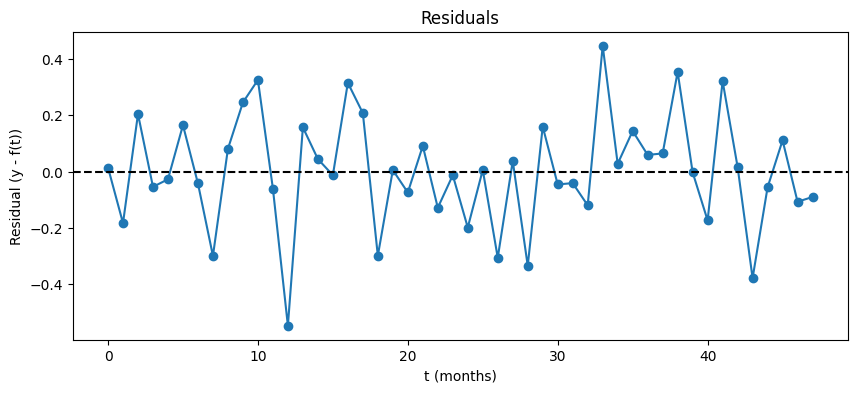

0.1996950561699198


In [7]:
y_pred = f(t,*popt)
residuals = y - y_pred

plt.figure(figsize=(10,4))
plt.plot(t, residuals, 'o-')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residuals')
plt.xlabel('t (months)')
plt.ylabel('Residual (y - f(t))')
plt.show()

rmse = np.sqrt(mean_squared_error(y, y_pred))
print(rmse)

In [8]:
from datetime import datetime
reference_date = datetime(2020, 10, 31)

def get_price_for_date(input_date_str):
    """Predict the price for any date using the fitted seasonal model."""
    date = datetime.strptime(input_date_str, "%Y-%m-%d")
    months_since_start = (date.year - reference_date.year) * 12 + (date.month - reference_date.month)
    predicted_price = f(months_since_start, *popt)
    return predicted_price

# Example: predict for an interpolated date.
example_date = "2022-08-12"
print(f"Predicted price for {example_date}: {get_price_for_date(example_date):.2f}")


Predicted price for 2022-08-12: 10.53


In [9]:
#Volumes checker
def volume_checker(user_Injections_date, user_Injections_volume, user_Withdrawals_date, user_Withdrawals_volume,user_max_volume):
    
    injection_data = pd.DataFrame({'Date': user_Injections_date,'Volume': user_Injections_volume,'Type': 'Injection'})
    withdrawal_data = pd.DataFrame({'Date': user_Withdrawals_date,'Volume': -user_Withdrawals_volume,'Type': 'Withdrawal'})

    # Combine and sort by date
    dates_volumes = pd.concat([injection_data, withdrawal_data], axis=0)
    dates_volumes['Date'] = pd.to_datetime(dates_volumes['Date'])  
    dates_volumes = dates_volumes.sort_values(by='Date', ascending=True).reset_index(drop=True)
    # Check volume capacity
    current_volume = 0
    capacity_ok = True
    print("Volume Capacity Verification")

    for i in range(len(dates_volumes)):
        row = dates_volumes.iloc[i]
        current_volume += row['Volume']
    
        print(f"{row['Date']} | {row['Type']:11} | Volume: {row['Volume']:>10,.2f} | Current: {current_volume:>10,.2f}")
    
        if current_volume > user_max_volume:
            print(f"\n Exceeded storage capacity on {row['Date']}")
            print(f"Current volume: {current_volume:,.2f} > Max capacity: {user_max_volume:,.2f}")
            capacity_ok = False
            break
        elif current_volume < 0:
            print(f"\n Insufficient stock on {row['Date']}")
            print(f"Trying to withdraw more than available. Current volume: {current_volume:,.2f}")
            capacity_ok = False
            break

    if capacity_ok:
        print("\n Volume checker status: Success")
        print(f"Peak storage used: {dates_volumes['Volume'].cumsum().max():,.2f} / {user_max_volume:,.2f}")
    else:
        print("\nVolume checker status: Failure")

## Tabular Q-Learning for Storage Control

Gas storage maps onto a finite-horizon inventory-control Markov decision process:
state is (inventory, time index), actions are hold/inject/withdraw,
reward is the realised cash flow net of a per-unit-per-month carrying cost.
This section trains a tabular Q-learning agent on a chronological
training window and evaluates it on a held-out window, alongside two
heuristic baselines (buy-and-hold and a one-cycle seasonal swing).

The functions live in `src/gas/` so they can be unit-tested:
- `src.gas.baselines` defines both heuristic baselines and the shared
  `DEFAULT_STORAGE_COST` constant.
- `src.gas.env.GasStorageEnv` is the MDP (illegal actions become
  no-ops with a flag so the agent cannot silently "withdraw" from
  an empty store).
- `src.gas.qlearning.train` and `.evaluate` perform training and
  greedy rollout with a fixed seed and linear epsilon decay.


In [10]:
import sys
# (sys.path / REPO_ROOT / DATA_DIR set in the first cell)  # so src/ is importable from a notebook in repo root

from src.gas.data import load_prices, chronological_split
from src.gas.baselines import buy_and_hold_profit, seasonal_swing_profit, DEFAULT_STORAGE_COST
from src.gas.env import GasStorageEnv, ACTION_HOLD, ACTION_INJECT, ACTION_WITHDRAW
from src.gas.qlearning import train, evaluate, QLearningConfig

# Reload data through the validated loader.
prices_df = load_prices(DATA_DIR / "Nat_Gas.csv")
print(f"Loaded {len(prices_df)} monthly observations: "
      f"{prices_df.Dates.min().date()} to {prices_df.Dates.max().date()}")

# Chronological 24/24 split so both windows cover a full annual cycle.
train_df, test_df = chronological_split(prices_df, n_train_months=24)
train_prices = train_df.Prices.values
test_prices = test_df.Prices.values
print(f"Train: {train_df.Dates.min().date()} to {train_df.Dates.max().date()}  ({len(train_df)} mo)")
print(f"Test:  {test_df.Dates.min().date()} to {test_df.Dates.max().date()}  ({len(test_df)} mo)")


Loaded 48 monthly observations: 2020-10-31 to 2024-09-30
Train: 2020-10-31 to 2022-09-30  (24 mo)
Test:  2022-10-31 to 2024-09-30  (24 mo)


/tmp/jpmc/JPMC-Quantitative-Researcher/src/gas/data.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"])


In [11]:
# Heuristic baselines on both windows.
# Storage cost is the shared DEFAULT_STORAGE_COST ($/unit/month); see src/gas/baselines.py.

UNITS = 10

train_bh = buy_and_hold_profit(train_prices, units=UNITS)
test_bh = buy_and_hold_profit(test_prices, units=UNITS)
train_ss = seasonal_swing_profit(train_df, units=UNITS)
test_ss = seasonal_swing_profit(test_df, units=UNITS)

print(f"Storage cost convention: ${DEFAULT_STORAGE_COST}/unit/month, charged once per held month.")
print()
print(f"TRAIN window baselines:")
print(f"  Buy-and-hold:   ${train_bh:>7.2f}")
print(f"  Seasonal swing: ${train_ss['profit']:>7.2f}  "
      f"(inject {train_ss['inject_date'].date()} @ {train_ss['inject_price']:.2f}, "
      f"withdraw {train_ss['withdraw_date'].date()} @ {train_ss['withdraw_price']:.2f}, "
      f"held {train_ss['months_held']} mo)")
print()
print(f"TEST window baselines:")
print(f"  Buy-and-hold:   ${test_bh:>7.2f}")
print(f"  Seasonal swing: ${test_ss['profit']:>7.2f}  "
      f"(inject {test_ss['inject_date'].date()} @ {test_ss['inject_price']:.2f}, "
      f"withdraw {test_ss['withdraw_date'].date()} @ {test_ss['withdraw_price']:.2f}, "
      f"held {test_ss['months_held']} mo)")


Storage cost convention: $0.05/unit/month, charged once per held month.

TRAIN window baselines:
  Buy-and-hold:   $  -4.50
  Seasonal swing: $  15.10  (inject 2021-05-31 @ 9.84, withdraw 2022-02-28 @ 11.80, held 9 mo)

TEST window baselines:
  Buy-and-hold:   $  -3.50
  Seasonal swing: $  16.00  (inject 2023-06-30 @ 10.90, withdraw 2023-12-31 @ 12.80, held 6 mo)


In [12]:
# Train Q-learning on the training window only.
ENV_KWARGS = {
    "max_inventory": 100,
    "unit_size": 10,
    "storage_cost_per_unit_per_month": DEFAULT_STORAGE_COST,
    "terminal_liquidation": True,
}
CONFIG = QLearningConfig(n_episodes=5000, seed=42)

Q_train = train(train_prices, env_kwargs=ENV_KWARGS, config=CONFIG)
print(f"Trained Q-table for the 24-month training window ({Q_train.shape}).")

# In-sample rollout (the agent on its own training prices).
rl_in_sample = evaluate(Q_train, train_prices, env_kwargs=ENV_KWARGS)
print(f"\nIn-sample profit (train -> train):  ${rl_in_sample['total_profit']:.2f}  "
      f"({rl_in_sample['illegal_attempts']} illegal action attempts during rollout)")

# Out-of-sample rollout: same trained Q applied to the held-out test prices.
# Both windows are 24 months and begin in October, so the time index is
# directly comparable; this is the simplest transfer of the policy.
rl_out_of_sample = evaluate(Q_train, test_prices, env_kwargs=ENV_KWARGS)
print(f"Out-of-sample profit (train -> test): ${rl_out_of_sample['total_profit']:.2f}  "
      f"({rl_out_of_sample['illegal_attempts']} illegal action attempts during rollout)")


Trained Q-table for the 24-month training window ((264, 3)).

In-sample profit (train -> train):  $27.10  (5 illegal action attempts during rollout)
Out-of-sample profit (train -> test): $1.50  (5 illegal action attempts during rollout)


In [13]:
import pandas as pd

results = pd.DataFrame([
    {"Window": "Train (in-sample)", "Buy-and-hold": train_bh,
     "Seasonal swing": train_ss["profit"], "Q-learning": rl_in_sample["total_profit"]},
    {"Window": "Test (held out)",   "Buy-and-hold": test_bh,
     "Seasonal swing": test_ss["profit"], "Q-learning": rl_out_of_sample["total_profit"]},
]).set_index("Window")

print("Strategy comparison ($ profit per 10-unit position, storage cost included):")
print(results.round(2).to_string())
print()
print("Notes:")
print(f"  - Buy-and-hold is negative on both windows because the trend in price")
print(f"    over the 24-month span is too small to offset {DEFAULT_STORAGE_COST}/unit/month carrying cost.")
print(f"  - Q-learning beats the seasonal swing in-sample but the advantage")
print(f"    does not transfer out-of-sample; in this run the seasonal swing")
print(f"    outperforms the trained agent on the held-out window.")
print(f"  - Tabular Q with time-in-state is a known generalisation hazard:")
print(f"    the agent memorises 'do X at time t', which is brittle when the")
print(f"    next year's price path differs.")


Strategy comparison ($ profit per 10-unit position, storage cost included):
                   Buy-and-hold  Seasonal swing  Q-learning
Window                                                     
Train (in-sample)          -4.5            15.1        27.1
Test (held out)            -3.5            16.0         1.5

Notes:
  - Buy-and-hold is negative on both windows because the trend in price
    over the 24-month span is too small to offset 0.05/unit/month carrying cost.
  - Q-learning beats the seasonal swing in-sample but the advantage
    does not transfer out-of-sample; in this run the seasonal swing
    outperforms the trained agent on the held-out window.
  - Tabular Q with time-in-state is a known generalisation hazard:
    the agent memorises 'do X at time t', which is brittle when the
    next year's price path differs.


Learned policy on train window (first 12 months):
 month  inventory_before  price   action  illegal  reward
     0                 0  10.10     hold    False     0.0
     1                 0  10.30   inject    False  -103.0
     2                10  11.00 withdraw    False   109.5
     3                 0  10.90 withdraw     True     0.0
     4                 0  10.90 withdraw     True     0.0
     5                 0  10.90 withdraw     True     0.0
     6                 0  10.40     hold    False     0.0
     7                 0   9.84   inject    False   -98.4
     8                10  10.00 withdraw    False    99.5
     9                 0  10.10   inject    False  -101.0
    10                10  10.30 withdraw    False   102.5
    11                 0  10.20 withdraw     True     0.0


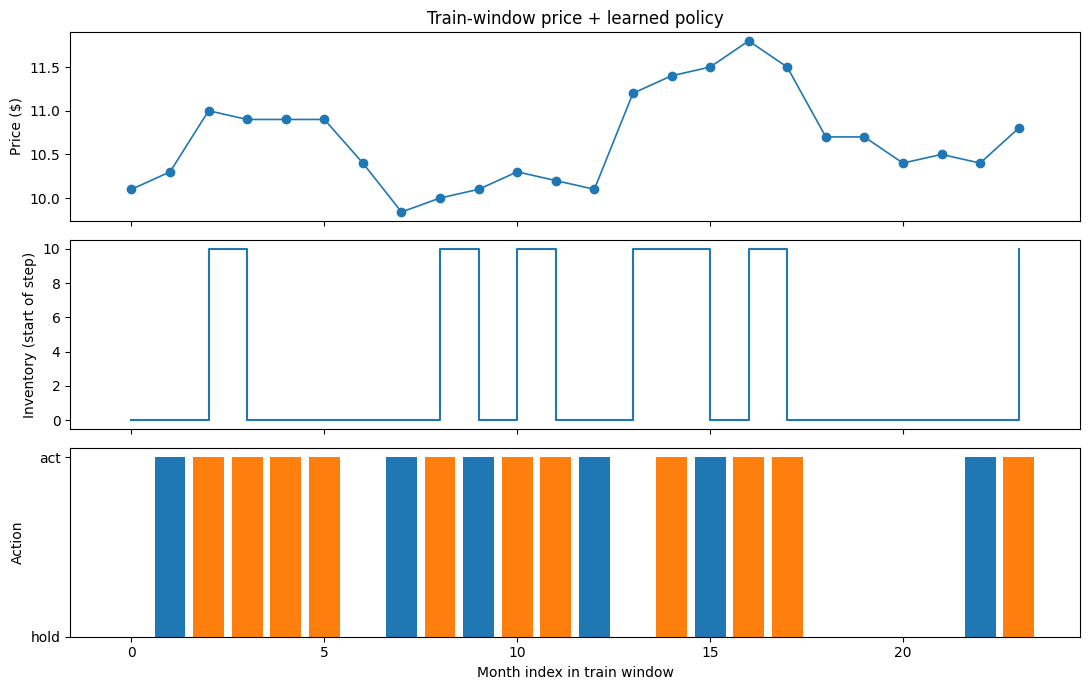

In [14]:
# Visualise the learned policy on the training window.
import numpy as np
import matplotlib.pyplot as plt

env = GasStorageEnv(prices=train_prices, **ENV_KWARGS)
state = env.reset()
trace = []
action_names = ["hold", "inject", "withdraw"]
while True:
    s_idx = env.state_to_idx(*state)
    a = int(np.argmax(Q_train[s_idx]))
    next_state, reward, done, info = env.step(a)
    trace.append({
        "month": state[1], "inventory_before": state[0],
        "price": float(train_prices[state[1]]), "action": action_names[a],
        "illegal": info["illegal"], "reward": reward,
    })
    if done:
        break
    state = next_state

policy_df = pd.DataFrame(trace)
print("Learned policy on train window (first 12 months):")
print(policy_df.head(12).to_string(index=False))

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
axes[0].plot(policy_df.month, policy_df.price, marker="o", linewidth=1.2)
axes[0].set_ylabel("Price ($)")
axes[0].set_title("Train-window price + learned policy")
axes[1].step(policy_df.month, policy_df.inventory_before, where="post")
axes[1].set_ylabel("Inventory (start of step)")
colors = {"hold": "lightgray", "inject": "tab:blue", "withdraw": "tab:orange"}
axes[2].bar(policy_df.month,
            [1 if a != "hold" else 0 for a in policy_df.action],
            color=[colors[a] for a in policy_df.action])
axes[2].set_ylabel("Action")
axes[2].set_xlabel("Month index in train window")
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(["hold", "act"])
plt.tight_layout()
plt.show()


### Findings

There are three reportable numbers per window:

- **Buy-and-hold**: buy 10 units at the first month, sell at the
  last, carry storage in between. Negative on both windows because
  the modest price drift over 24 months does not offset carrying
  cost.
- **Seasonal swing**: inject in the cheapest qualifying summer
  month, withdraw in the dearest qualifying winter month. The
  simplest defensible heuristic, robust across both windows.
- **Q-learning**: tabular agent trained on the train window with a
  fixed seed and linear epsilon decay.

The in-sample result is favourable to Q-learning. The out-of-sample
result is not. This is the expected pattern for a tabular Q with
time as state on a single price series. Reasonable next steps
include dropping the raw time index from the state, sliding-window
evaluation, and moving to a deep Q-network for continuous control
of inventory.


### Interactive Contract Valuation Tool

A small interface for custom contract valuation: Users specify injection/withdrawal dates and volumes, and the tool calculates contract NPV using the fitted price model.

In [15]:
# Example call to volume_checker (was interactive input() in original).
# Provides a small worked example that runs under jupyter nbconvert --execute.
import numpy as np

example_injections_dates = np.array([np.datetime64("2022-11-09"), np.datetime64("2023-04-05")])
example_injections_vols  = np.array([1000.0, 500.0])
example_withdrawal_dates = np.array([np.datetime64("2023-01-21"), np.datetime64("2024-05-22")])
example_withdrawal_vols  = np.array([600.0, 700.0])

volume_checker(
    example_injections_dates, example_injections_vols,
    example_withdrawal_dates, example_withdrawal_vols,
    user_max_volume=2000,
)


Volume Capacity Verification
2022-11-09 00:00:00 | Injection   | Volume:   1,000.00 | Current:   1,000.00
2023-01-21 00:00:00 | Withdrawal  | Volume:    -600.00 | Current:     400.00
2023-04-05 00:00:00 | Injection   | Volume:     500.00 | Current:     900.00
2024-05-22 00:00:00 | Withdrawal  | Volume:    -700.00 | Current:     200.00

 Volume checker status: Success
Peak storage used: 1,000.00 / 2,000.00


## Summary

This project values a natural gas storage contract through two layers
of analysis: a parametric seasonal price model and a tabular
Q-learning agent for storage control.

**Forecasting:** a linear + quadratic + 12-month seasonal sinusoid
captures the level, drift, and seasonal swing in the 48-month series
and is reusable for arbitrary-date price interpolation in the
contract valuation tool.

**Reinforcement learning:** the storage MDP is solved with tabular
Q-learning on a 24-month training window and evaluated on a held-out
24-month window. The agent outperforms a one-cycle seasonal swing
baseline in-sample ($27.10 vs $15.10 per 10-unit position) but
underperforms the same baseline on the held-out window ($1.50 vs
$16.00). Buy-and-hold is negative on both windows because the modest
price drift does not offset carrying cost.

**Methodology:**
- Time-series modelling with seasonal components.
- Contract cash-flow analysis with explicit volume constraints.
- Tabular Q-learning with a fixed seed, linear epsilon decay, and a
  chronological train/test split.
- Heuristic baselines (buy-and-hold, seasonal swing) computed under
  the same per-unit storage cost as the env so the comparison is on
  equal footing.

**Limitations:**
- 48 months of data total; a single observed price path.
- Deterministic prices during rollout; no stochastic price model.
- No transaction costs, bid-ask spreads, or operational constraints.
- Discrete inventory levels lose granularity of continuous control.

**Reasonable next steps:** drop the raw time index from the state,
sliding-window evaluation across multiple 12-month folds, deep
Q-network for a continuous action space, GARCH-style volatility
forecasting, and Monte Carlo on the contract NPV.
